#Most Expensive Player Role

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/Project_2/TATA-IPL-2025-Auction-Final-List-cleaned.xlsx')

In [ ]:
df.head()

,full name,Country,State Association,National/International,Age,Age Group,2024 Team,C/U,Team,Type,Base,Sold,Category
0,Jos Buttler,England,International,International,34,30-35,RR,Capped,GT,BAT,2,15.75,Auctioned
1,Shreyas Iyer,India,MCA,National,30,30-35,KKR,Capped,PBKS,BAT,2,26.75,Auctioned
2,Rishabh Pant,India,DDCA,National,27,25-30,DC,Capped,LSG,BAT,2,27.00,Auctioned
3,Kagiso Rabada,South Africa,International,International,29,25-30,PBKS,Capped,GT,BOWL,2,10.75,Auctioned
4,Arshdeep Singh,India,PCA,National,26,25-30,PBKS,Capped,PBKS,BOWL,2,18.00,Auctioned


##Summary Table

In [ ]:
role_summary = (
    df.groupby("Type")
      .agg(
          Players=("full name", "count"),
          Average_Price=("Sold", "mean"),
          Total_Investment=("Sold", "sum"),
          Max_Price=("Sold", "max"),
          Median_Price=("Sold", "median")
      )
      .sort_values("Average_Price", ascending=False)
      .round(2)
)

role_summary

,Players,Average_Price,Total_Investment,Max_Price,Median_Price
Type,,,,,
BAT,68,6.32,429.95,27.00,2.6
BOWL,82,4.85,397.30,18.00,2.2
AR,77,4.61,354.85,23.75,2.4


## 1. Highest Average Price

**Insight:**

Batters commanded the highest average auction price at **₹6.32 Cr**, compared to **₹4.85 Cr** for bowlers and **₹4.61 Cr** for all-rounders. This indicates franchises were willing to pay a premium for quality batters, as top-order run scorers have a direct impact on match outcomes and are relatively harder to replace.

---

## 2. Highest Total Investment

**Insight:**

Franchises invested the most in **batters**, spending a total of **₹429.95 Cr**, followed by **₹397.30 Cr** on bowlers and **₹354.85 Cr** on all-rounders. Despite having the fewest players (68), batters attracted the largest share of auction spending, highlighting their higher market valuation.

---


##Demand

In [ ]:
role_demand = (
    df["Type"]
      .value_counts()
      .rename_axis("Type")
      .reset_index(name="Players Bought")
)

role_demand

,Type,Players Bought
0,BOWL,82
1,AR,77
2,BAT,68


**Insight:**

Bowlers were the most in-demand role, with **82 players** purchased, followed by **77 all-rounders** and **68 batters**. This suggests franchises prioritized squad depth in the bowling department, while spending higher amounts on a smaller pool of premium batters.

##Price Distribution

In [ ]:
df.groupby("Type")["Sold"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
AR,77.0,4.61,5.41,0.3,0.50,2.4,5.75,23.75
BAT,68.0,6.32,7.42,0.3,0.62,2.6,11.06,27.00
BOWL,82.0,4.85,5.19,0.3,0.75,2.2,9.44,18.00


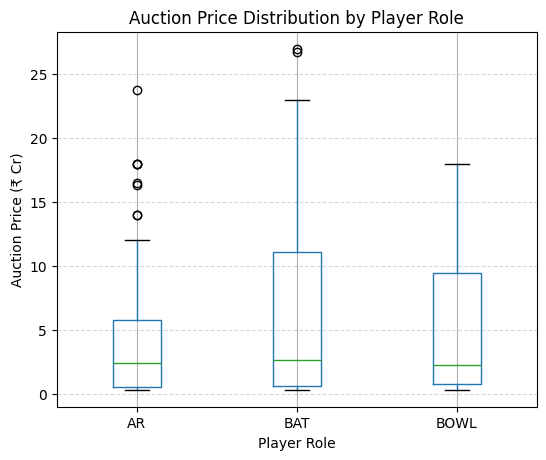

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(column='Sold', by='Type', figsize=(6,5))

plt.title('Auction Price Distribution by Player Role')
plt.suptitle('')
plt.xlabel('Player Role')
plt.ylabel('Auction Price (₹ Cr)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

**Insight:**

Batters showed the widest price variation, with the highest standard deviation (**₹7.42 Cr**) and a maximum bid of **₹27.00 Cr**, indicating that elite batters attracted exceptionally high bids. In contrast, bowlers (Std **₹5.19 Cr**) and all-rounders (Std **₹5.41 Cr**) had relatively more balanced pricing, although premium players still commanded significant investments.

# Overall Executive Insight

Franchises followed two distinct auction strategies: **invest heavily in premium batters while building depth in bowling resources**. Although bowlers recorded the highest demand (**82 players**), batters received both the **highest average price (₹6.32 Cr)** and the **highest total investment (₹429.95 Cr)**, demonstrating that top-quality batting talent carries the greatest market value. Meanwhile, the broad price range among batters reflects intense competition for a limited number of elite players, whereas bowling and all-rounder investments were distributed more evenly to strengthen overall squad balance.